--- RESULTADOS (Média do LiDAR recortada - Abordagem A) ---
Período Analisado: 2021-09-16 21:00:00 até 2021-11-08 14:00:00 (UTC)
Total de horas coincidentes: 1266
Coeficiente de Correlação de Pearson: 0.6636
Erro Médio Absoluto (MAE): 1.5388 m/s
Raiz do Erro Quadrático Médio (RMSE): 1.8062 m/s
Bias (Viés): -1.3117 m/s



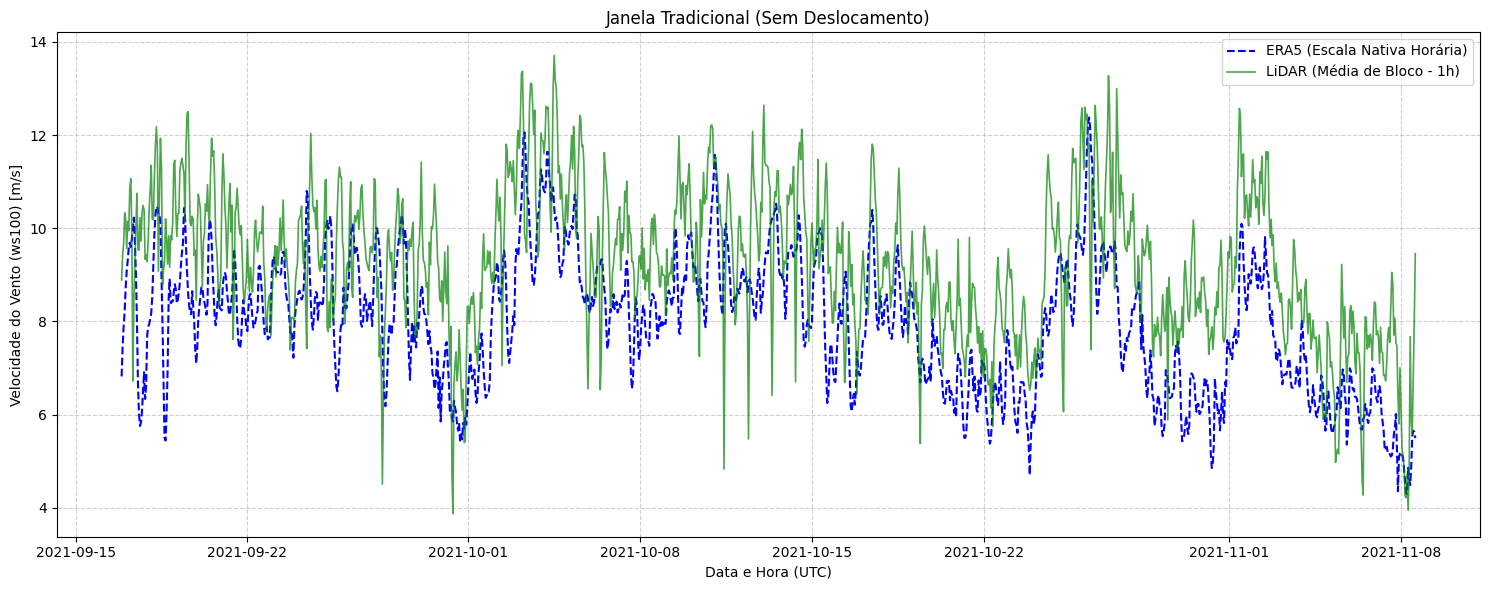

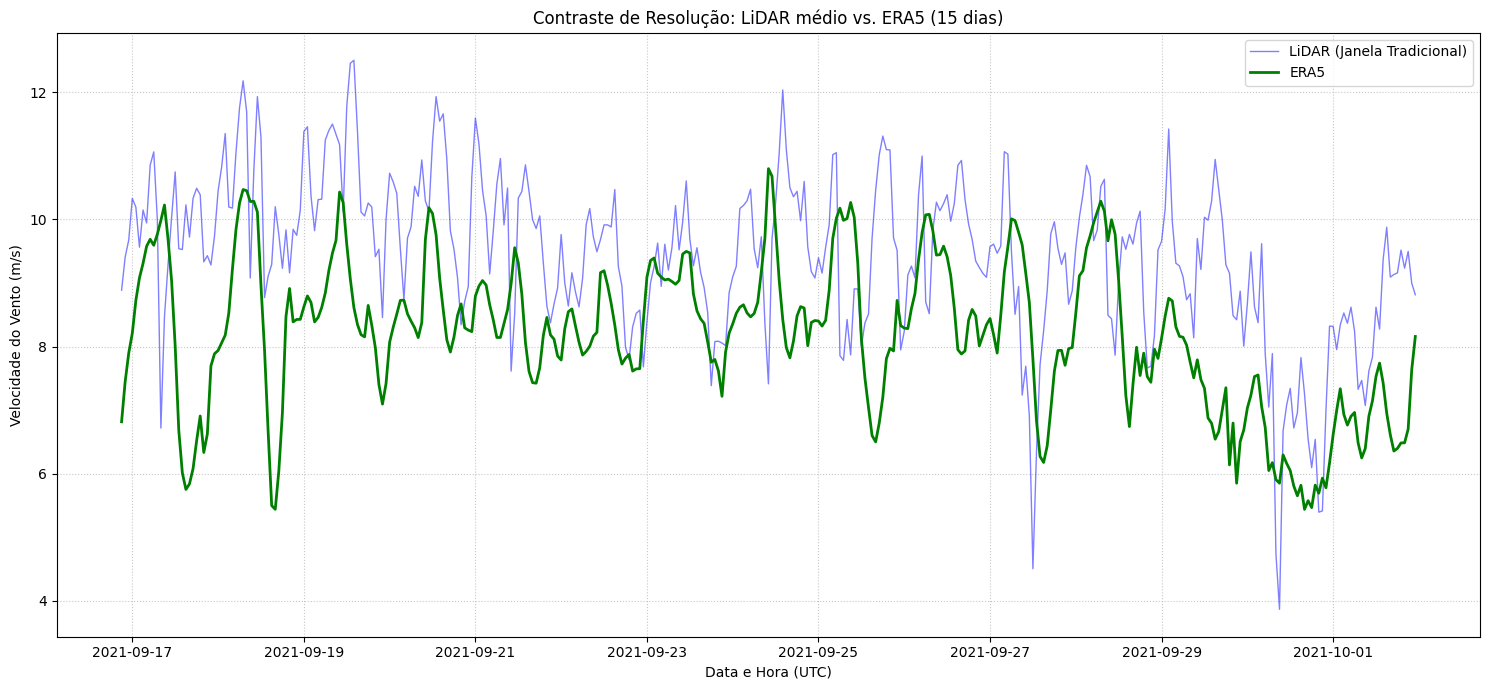

Evolução do RMSE Diário (m/s):
valid_time
2021-09-16    1.939930
2021-09-17    2.566108
2021-09-18    2.213672
2021-09-19    2.169868
2021-09-20    1.816595
2021-09-21    1.842644
2021-09-22    1.174295
2021-09-23    0.598541
2021-09-24    1.839421
2021-09-25    2.181474
2021-09-26    1.363925
2021-09-27    1.733971
2021-09-28    1.436218
2021-09-29    2.301673
2021-09-30    1.408538
2021-10-01    1.828787
Freq: D, dtype: float64


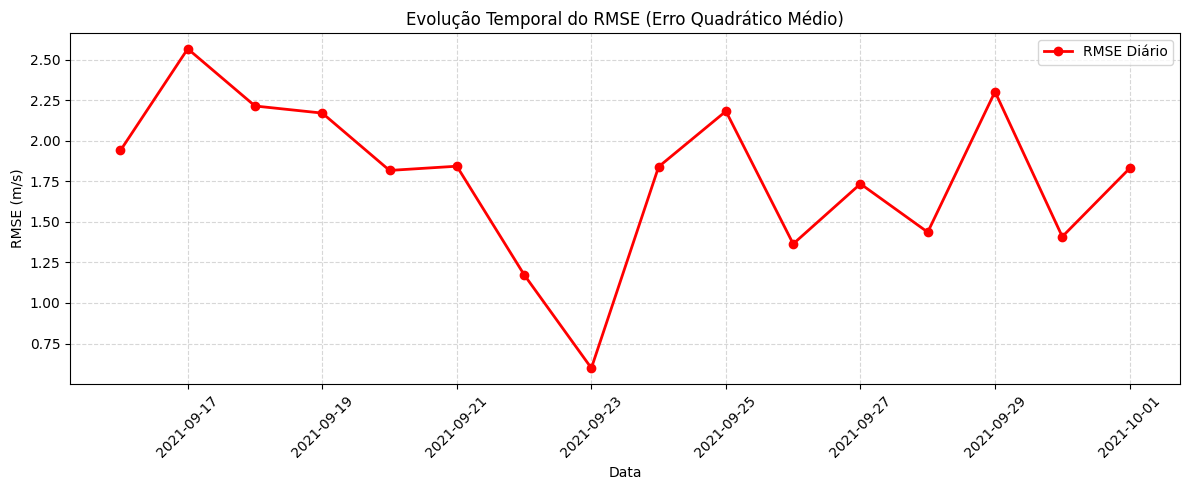

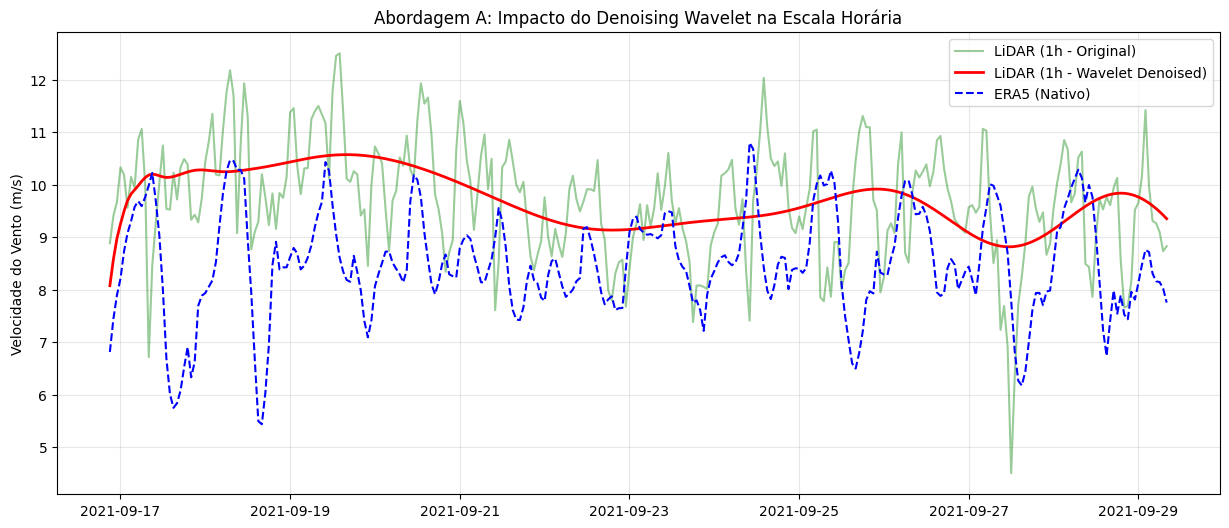

Evolução do RMSE Diário COM WAVELET (m/s):
valid_time
2021-09-16    1.160833
2021-09-17    2.575384
2021-09-18    2.365480
2021-09-19    2.021959
2021-09-20    1.793147
2021-09-21    1.385477
2021-09-22    1.099954
2021-09-23    0.890877
2021-09-24    1.003230
2021-09-25    1.789011
2021-09-26    0.952693
2021-09-27    1.344717
2021-09-28    1.552240
2021-09-29    1.665943
2021-09-30    1.424700
2021-10-01    1.546554
Freq: D, dtype: float64


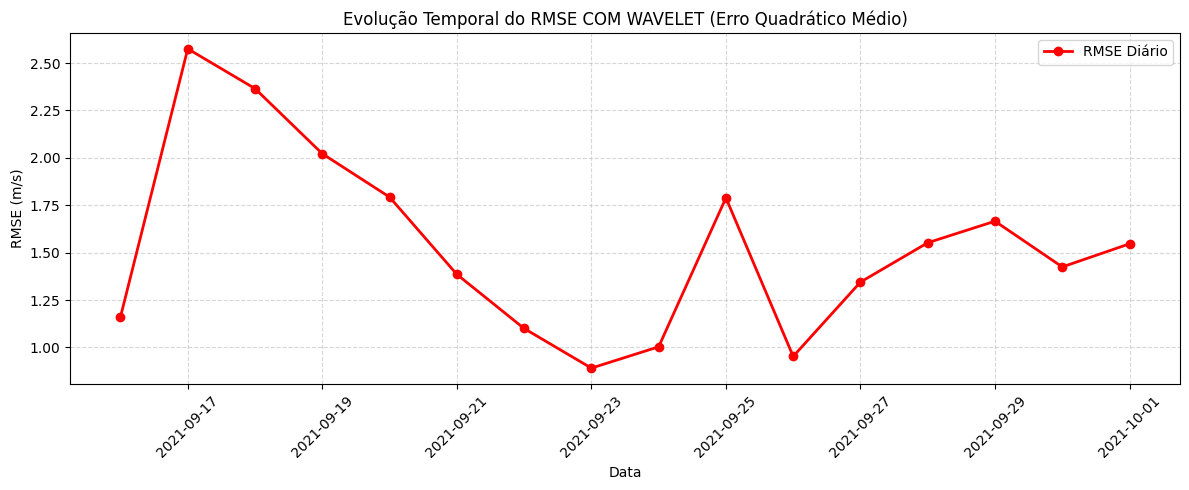

--- RESULTADOS FINAIS (Abordagem A + Wavelet) ---
Métricas (Original): MAE: 1.5388 | RMSE: 1.8062 | Bias: -1.3117 | Correlação: 0.6636
Métricas (Wavelet):  MAE: 1.3726 | RMSE: 1.5865 | Bias: -1.3187 | Correlação: 0.7913



In [8]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pywt
from sklearn.metrics import mean_absolute_error, mean_squared_error

data_path = '/content/data/era5_dataset.nc'
ds_era5 = xr.open_dataset(data_path)
df_lidar = pd.read_csv('/content/data/dataset.csv')

colunas_interesse = ['d2m', 't2m', 'sp', 'u100', 'v100', 'z']
colunas_presentes = [c for c in colunas_interesse if c in ds_era5.data_vars]
ds_era5['ws100'] = (ds_era5.u100**2 + ds_era5.v100**2)**0.5
era5_ponto = ds_era5.sel(latitude=-2.69, longitude=-42.56, method='nearest')
era5_periodo = era5_ponto.ws100.sel(valid_time=slice('2021-09-15', '2021-11-08'))
ds_10min = era5_periodo.resample(valid_time='10min').interpolate('linear')

df_lidar['valid_time'] = pd.to_datetime(df_lidar[['year', 'month', 'day', 'hour', 'minute']])
df_lidar['valid_time'] = df_lidar['valid_time'] + pd.Timedelta(hours=3) # Conversão do UTC
df_lidar = df_lidar.set_index('valid_time')
lidar_periodo = df_lidar['ws100'].loc['2021-09-15':'2021-11-08']

#lidar_horario = df_lidar[['ws100']].resample('1h', offset='30min').mean() TESTE
lidar_horario = df_lidar[['ws100']].resample('1h').mean()

# Deslocamos o índice resultante em +30 minutos para frente. TESTE
# lidar_horario.index = lidar_horario.index + pd.Timedelta(minutes=30)
df_lidar_final = lidar_horario.rename(columns={'ws100': 'ws100_lidar'})

# Prepara o ERA5 data for join
df_era5_final = era5_periodo.to_dataframe().reset_index().set_index('valid_time')
df_era5_final = df_era5_final.rename(columns={'ws100': 'ws100_era5'}).drop(columns=['number', 'latitude', 'longitude'])

# Alinhamento Perfeito por Interseção (Inner Join)
# Isso garante que apenas os timestamps presentes em ambos os datasets (período do LiDAR) sejam avaliados
df_analise = df_era5_final.join(df_lidar_final, how='inner')

# Filtragem explícita para garantir o escopo do LiDAR fornecido
df_analise = df_analise.loc['2021-09-16 18:00:00':'2021-11-08 14:00:00']

# Cálculo das Métricas Estatísticas
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Cálculo do Bias (Viés): Média das diferenças
def calculate_bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

corr_orig = df_analise['ws100_era5'].corr(df_analise['ws100_lidar'])
mae_orig = mean_absolute_error(df_analise['ws100_lidar'], df_analise['ws100_era5'])
rmse_orig = root_mean_squared_error(df_analise['ws100_lidar'], df_analise['ws100_era5'])
bias_orig = calculate_bias(df_analise['ws100_lidar'], df_analise['ws100_era5'])

print(f"--- RESULTADOS (Média do LiDAR recortada - Abordagem A) ---")
print(f"Período Analisado: {df_analise.index.min()} até {df_analise.index.max()} (UTC)")
print(f"Total de horas coincidentes: {len(df_analise)}")
print(f"Coeficiente de Correlação de Pearson: {corr_orig:.4f}")
print(f"Erro Médio Absoluto (MAE): {mae_orig:.4f} m/s")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse_orig:.4f} m/s")
print(f"Bias (Viés): {bias_orig:.4f} m/s\n")

# Construção do Gráfico Comparativo com Marcadores de Coincidência
plt.figure(figsize=(15, 6))
plt.plot(df_analise.index, df_analise['ws100_era5'],label='ERA5 (Escala Nativa Horária)',color='blue', lw=1.5, markersize=4,linestyle='--', markerfacecolor='black')
plt.plot(df_analise.index, df_analise['ws100_lidar'],label='LiDAR (Média de Bloco - 1h)',color='green', alpha=0.7, lw=1.2, markersize=4, markerfacecolor='red')

plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Velocidade do Vento (ws100) [m/s]')
plt.title('Janela Tradicional (Sem Deslocamento)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Filtragem dos primeiros 15 dias
df_primeira_semana = df_analise.loc['2021-09-16':'2021-10-01']

plt.figure(figsize=(15, 7))

# Plot do LiDAR (Janela tradicional)
plt.plot(df_primeira_semana.index, df_primeira_semana['ws100_lidar'],
         label='LiDAR (Janela Tradicional)', color='blue', alpha=0.5, linewidth=1)

# Plot do ERA5 (Reanálise pura)
plt.plot(df_primeira_semana.index, df_primeira_semana['ws100_era5'],
         label='ERA5', color='green', linewidth=2)

plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Velocidade do Vento (m/s)')
plt.title('Contraste de Resolução: LiDAR médio vs. ERA5 (15 dias)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Cálculo do RMSE diário para quantificar o erro por dia, criação da variável D
rmse_diario = df_primeira_semana.resample('D').apply(
    lambda x: np.sqrt(mean_squared_error(x['ws100_lidar'], x['ws100_era5']))
)
print("Evolução do RMSE Diário (m/s):")
print(rmse_diario)

# Representação Gráfica
plt.figure(figsize=(12, 5))
plt.plot(rmse_diario.index, rmse_diario.values, marker='o', linestyle='-', color='red', linewidth=2, label='RMSE Diário')

plt.title('Evolução Temporal do RMSE (Erro Quadrático Médio)')
plt.ylabel('RMSE (m/s)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 1. Função de Denoising Wavelet (Configuração do Projeto)
def wavelet_denoising(data, wavelet='sym18', level=2):
    # Decompõe o sinal em coeficientes de aproximação e detalhe
    coeff = pywt.wavedec(data, wavelet, mode="per")
    # Zera os coeficientes de detalhe (ruído de alta frequência)
    coeff[1:] = [np.zeros_like(v) for v in coeff[1:]]
    # Reconstrói o sinal apenas com a aproximação suavizada
    return pywt.waverec(coeff, wavelet, mode="per")

# 2. Aplicação da Wavelet na Verdade de Campo (LiDAR Horário)
# Aplicamos ao sinal já alinhado no df_analise
df_analise['ws100_lidar_wavelet'] = wavelet_denoising(df_analise['ws100_lidar'].values)

# 3. Cálculo das Novas Métricas de Erro (ERA5 vs LiDAR Denoised)
def calculate_metrics(y_true, y_pred):
    mae_metric = mean_absolute_error(y_true, y_pred)
    rmse_metric = np.sqrt(mean_squared_error(y_true, y_pred))
    bias_metric = np.mean(y_pred - y_true)
    corr_metric = np.corrcoef(y_true, y_pred)[0, 1]
    return mae_metric, rmse_metric, bias_metric, corr_metric

# 4. Visualização do Impacto da Wavelet
plt.figure(figsize=(15, 6))
plt.plot(df_analise.index[:300], df_analise['ws100_lidar'][:300], label='LiDAR (1h - Original)', alpha=0.4, color='green')
plt.plot(df_analise.index[:300], df_analise['ws100_lidar_wavelet'][:300], label='LiDAR (1h - Wavelet Denoised)', color='red', linewidth=2)
plt.plot(df_analise.index[:300], df_analise['ws100_era5'][:300], label='ERA5 (Nativo)', color='blue', linestyle='--')

plt.title('Abordagem A: Impacto do Denoising Wavelet na Escala Horária')
plt.ylabel('Velocidade do Vento (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo do RMSE diário COM WAVELET
rmse_diario_wav = df_analise.loc['2021-09-16':'2021-10-01'].resample('D').apply(
    lambda x: np.sqrt(mean_squared_error(x['ws100_lidar_wavelet'], x['ws100_era5']))
)
print("Evolução do RMSE Diário COM WAVELET (m/s):")
print(rmse_diario_wav)

# Representação Gráfica
plt.figure(figsize=(12, 5))
plt.plot(rmse_diario_wav.index, rmse_diario_wav.values, marker='o', linestyle='-', color='red', linewidth=2, label='RMSE Diário')

plt.title('Evolução Temporal do RMSE COM WAVELET (Erro Quadrático Médio)')
plt.ylabel('RMSE (m/s)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Métricas com sinal original
mae_orig, rmse_orig, bias_orig, corr_orig = calculate_metrics(df_analise['ws100_lidar'], df_analise['ws100_era5'])

# Métricas com sinal suavizado pela Wavelet
mae_wav, rmse_wav, bias_wav, corr_wav = calculate_metrics(df_analise['ws100_lidar_wavelet'], df_analise['ws100_era5'])

print(f"--- RESULTADOS FINAIS (Abordagem A + Wavelet) ---")
print(f"Métricas (Original): MAE: {mae_orig:.4f} | RMSE: {rmse_orig:.4f} | Bias: {bias_orig:.4f} | Correlação: {corr_orig:.4f}")
print(f"Métricas (Wavelet):  MAE: {mae_wav:.4f} | RMSE: {rmse_wav:.4f} | Bias: {bias_wav:.4f} | Correlação: {corr_wav:.4f}\n")

--- RESULTADOS (ERA5 Interpolado para 10min - Abordagem B) ---
Período Analisado: 2021-09-16 21:00:00 até 2021-11-08 17:20:00 (UTC)
Total de pontos coincidentes(10 min): 4195
Coeficiente de Correlação de Pearson: 0.6248
Erro Médio Absoluto (MAE): 1.5996 m/s
Raiz do Erro Quadrático Médio (RMSE): 1.8983 m/s
Bias (Viés): -1.3183 m/s



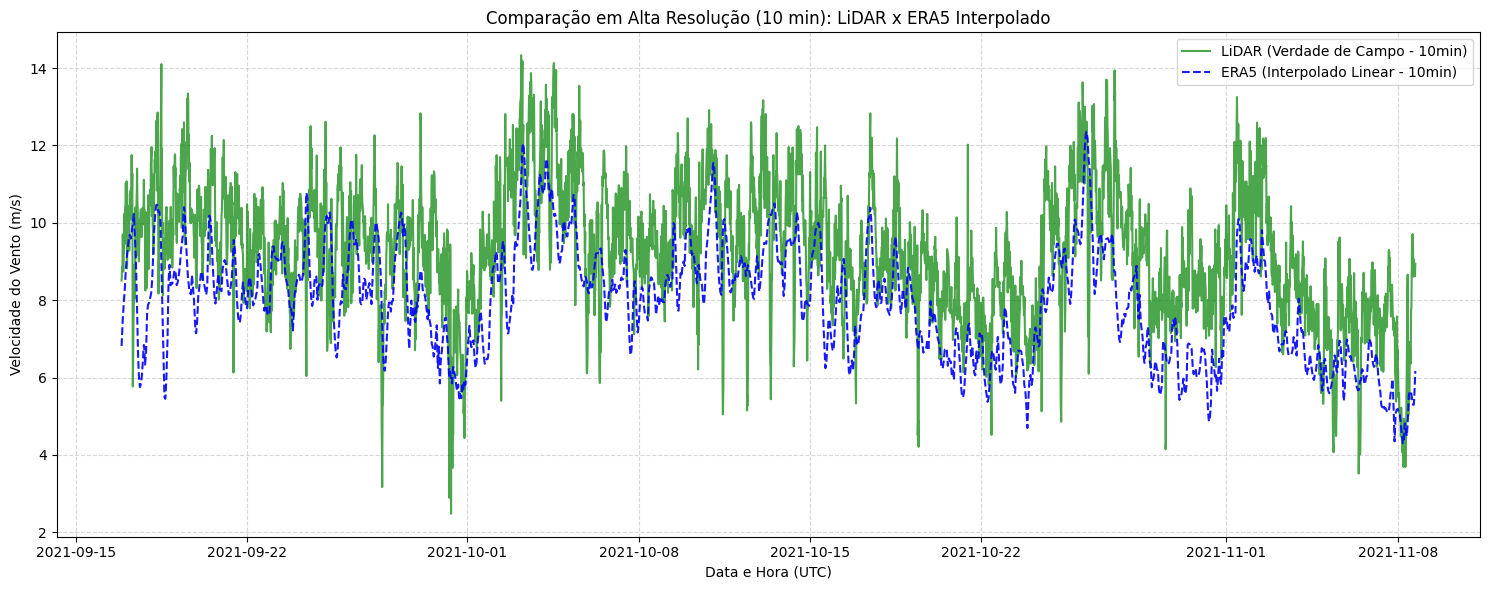

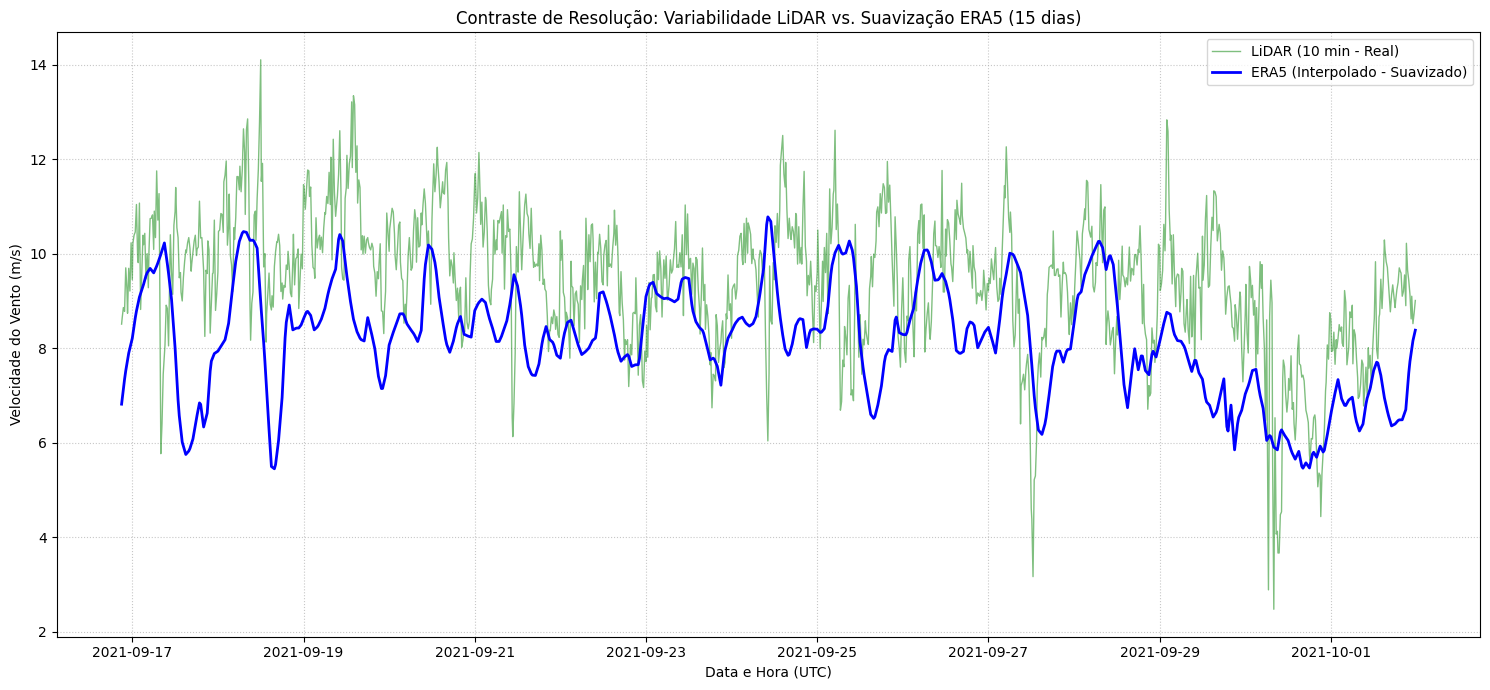

Evolução do RMSE Diário (m/s):
valid_time
2021-09-16    1.680044
2021-09-17    2.605915
2021-09-18    2.313779
2021-09-19    2.256775
2021-09-20    1.807149
2021-09-21    1.955623
2021-09-22    1.338705
2021-09-23    0.775766
2021-09-24    1.937904
2021-09-25    2.222321
2021-09-26    1.449228
2021-09-27    1.713781
2021-09-28    1.468098
2021-09-29    2.418750
2021-09-30    1.637144
2021-10-01    1.860356
Freq: D, dtype: float64


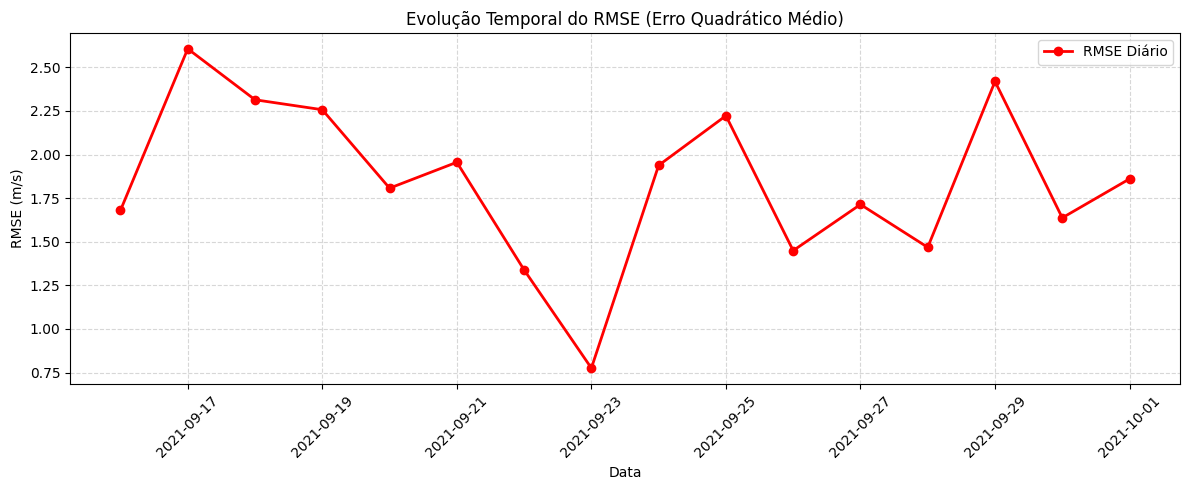

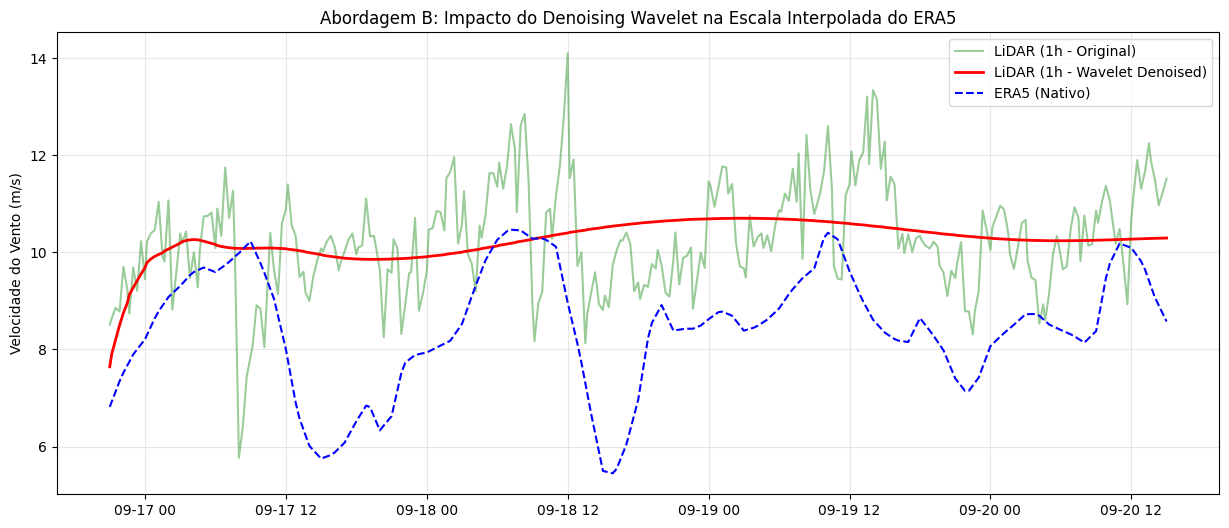

Evolução do RMSE Diário COM WAVELET (m/s):
valid_time
2021-09-16    1.233411
2021-09-17    2.408042
2021-09-18    2.444250
2021-09-19    2.014497
2021-09-20    1.723022
2021-09-21    1.433442
2021-09-22    1.134611
2021-09-23    0.818729
2021-09-24    1.251737
2021-09-25    1.359013
2021-09-26    1.268084
2021-09-27    1.260350
2021-09-28    1.239422
2021-09-29    2.183074
2021-09-30    0.927115
2021-10-01    1.766841
Freq: D, dtype: float64


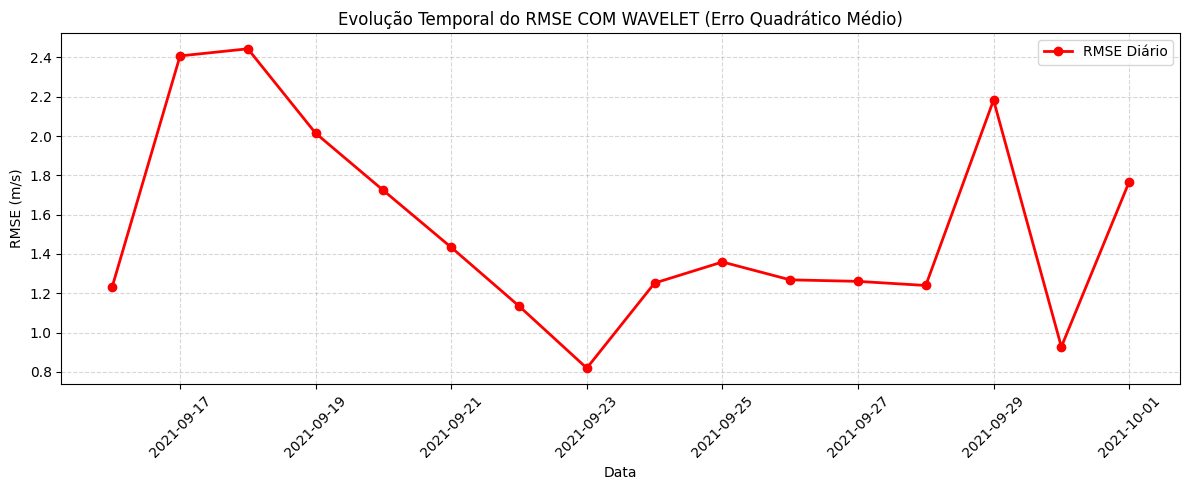

--- RESULTADOS FINAIS (Abordagem B + Wavelet) ---
Métricas (Original): MAE: 1.5996 | RMSE: 1.8983 | Bias: -1.3183 | Correlação: 0.6248
Métricas (Wavelet):  MAE: 1.3690 | RMSE: 1.5775 | Bias: -1.3174 | Correlação: 0.7998



In [9]:
# Utiliza-se a interpolação linear
era5_10min = era5_ponto.ws100.resample(valid_time='10min').interpolate('linear')
df_era5_final = era5_10min.to_dataframe().reset_index().set_index('valid_time')
df_era5_final = df_era5_final.rename(columns={'ws100': 'ws100_era5'})

# Processamento do LiDAR (Resolução nativa: 10min, padrão Local UTC-3)
df_lidar['valid_time'] = pd.to_datetime(df_lidar[['year', 'month', 'day', 'hour', 'minute']])
df_lidar = df_lidar.set_index('valid_time')

# AJUSTE UTC: Adicionamos 3 horas ao LiDAR para alinhar cronologicamente com o ERA5 assim como antes
df_lidar.index = df_lidar.index + pd.Timedelta(hours=3)
df_lidar_final = df_lidar[['ws100']].rename(columns={'ws100': 'ws100_lidar'})

# Alinhamento por Interseção (Inner Join)
# Mantém a resolução de 10 minutos, preservando a variabilidade real do sensor
df_analise = df_era5_final.join(df_lidar_final, how='inner')

# Filtragem do período de estudo
df_analise = df_analise.loc['2021-09-16':'2021-11-08']

# Cálculo das Métricas Estatísticas
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Cálculo do Bias (Viés): Média das diferenças
def calculate_bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

correlacao = df_analise['ws100_era5'].corr(df_analise['ws100_lidar'])
mae = mean_absolute_error(df_analise['ws100_lidar'], df_era5_final.loc[df_analise.index, 'ws100_era5'])
rmse = root_mean_squared_error(df_analise['ws100_lidar'], df_era5_final.loc[df_analise.index, 'ws100_era5'])
bias = calculate_bias(df_analise['ws100_lidar'], df_analise['ws100_era5'])

print(f"--- RESULTADOS (ERA5 Interpolado para 10min - Abordagem B) ---")
print(f"Período Analisado: {df_analise.index.min()} até {df_analise.index.max()} (UTC)")
print(f"Total de pontos coincidentes(10 min): {len(df_analise)}")
print(f"Coeficiente de Correlação de Pearson: {correlacao:.4f}")
print(f"Erro Médio Absoluto (MAE): {mae:.4f} m/s")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f} m/s")
print(f"Bias (Viés): {bias:.4f} m/s\n")

# Visualização Gráfica
plt.figure(figsize=(15, 6))
plt.plot(df_analise.index, df_analise['ws100_lidar'], label='LiDAR (Verdade de Campo - 10min)', color='green', alpha=0.7)
plt.plot(df_analise.index, df_analise['ws100_era5'], label='ERA5 (Interpolado Linear - 10min)', color='blue', linestyle='--', alpha=0.9)

plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Velocidade do Vento (m/s)')
plt.title('Comparação em Alta Resolução (10 min): LiDAR x ERA5 Interpolado')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Filtragem dos primeiros 15 dias
df_primeira_semana = df_analise.loc['2021-09-16':'2021-10-01']

plt.figure(figsize=(15, 7))

# Plot do LiDAR (Verdade de campo com alta variabilidade)
plt.plot(df_primeira_semana.index, df_primeira_semana['ws100_lidar'],
         label='LiDAR (10 min - Real)', color='green', alpha=0.5, linewidth=1)

# Plot do ERA5 (Curva suavizada pela interpolação de dados horários)
plt.plot(df_primeira_semana.index, df_primeira_semana['ws100_era5'],
         label='ERA5 (Interpolado - Suavizado)', color='blue', linewidth=2)

plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Velocidade do Vento (m/s)')
plt.title('Contraste de Resolução: Variabilidade LiDAR vs. Suavização ERA5 (15 dias)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Cálculo do RMSE diário para quantificar o erro por dia
rmse_diario = df_primeira_semana.resample('D').apply(
    lambda x: np.sqrt(mean_squared_error(x['ws100_lidar'], x['ws100_era5']))
)
print("Evolução do RMSE Diário (m/s):")
print(rmse_diario)

# Representação Gráfica
plt.figure(figsize=(12, 5))
plt.plot(rmse_diario.index, rmse_diario.values, marker='o', linestyle='-', color='red', linewidth=2, label='RMSE Diário')

plt.title('Evolução Temporal do RMSE (Erro Quadrático Médio)')
plt.ylabel('RMSE (m/s)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 1. Função de Denoising Wavelet (Corrigida para tamanhos ímpares)
def wavelet_denoising(data, wavelet='sym18', level=2):
    # Salva o tamanho original do dado que entrou
    tamanho_original = len(data)
    # Decompõe o sinal em coeficientes de aproximação e detalhe
    coeff = pywt.wavedec(data, wavelet, mode="per")
    # Zera os coeficientes de detalhe (ruído de alta frequência)
    coeff[1:] = [np.zeros_like(v) for v in coeff[1:]]
    # Reconstrói o sinal
    sinal_reconstruido = pywt.waverec(coeff, wavelet, mode="per")
    # Retorna o sinal cortando qualquer sobra gerada pelo padding da wavelet
    return sinal_reconstruido[:tamanho_original]

# 2. Aplicação da Wavelet na Verdade de Campo (ERA5 Interpolado)
# Aplica-se ao sinal já alinhado no df_analise
df_analise['ws100_lidar_wavelet'] = wavelet_denoising(df_analise['ws100_lidar'].values)

# 3. Cálculo das Novas Métricas de Erro (ERA5 vs LiDAR Denoised)
def calculate_metrics(y_true, y_pred):
    mae_metric = mean_absolute_error(y_true, y_pred)
    rmse_metric = np.sqrt(mean_squared_error(y_true, y_pred))
    bias_metric = np.mean(y_pred - y_true)
    corr_metric = np.corrcoef(y_true, y_pred)[0, 1]
    return mae_metric, rmse_metric, bias_metric, corr_metric

# 4. Visualização do Impacto da Wavelet
plt.figure(figsize=(15, 6))
plt.plot(df_analise.index[:300], df_analise['ws100_lidar'][:300], label='LiDAR (1h - Original)', alpha=0.4, color='green')
plt.plot(df_analise.index[:300], df_analise['ws100_lidar_wavelet'][:300], label='LiDAR (1h - Wavelet Denoised)', color='red', linewidth=2)
plt.plot(df_analise.index[:300], df_analise['ws100_era5'][:300], label='ERA5 (Nativo)', color='blue', linestyle='--')

plt.title('Abordagem B: Impacto do Denoising Wavelet na Escala Interpolada do ERA5')
plt.ylabel('Velocidade do Vento (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo do RMSE diário COM WAVELET
rmse_diario_wav = df_analise.loc['2021-09-16':'2021-10-01'].resample('D').apply(
    lambda x: np.sqrt(mean_squared_error(x['ws100_lidar_wavelet'], x['ws100_era5']))
)
print("Evolução do RMSE Diário COM WAVELET (m/s):")
print(rmse_diario_wav)

# Representação Gráfica
plt.figure(figsize=(12, 5))
plt.plot(rmse_diario_wav.index, rmse_diario_wav.values, marker='o', linestyle='-', color='red', linewidth=2, label='RMSE Diário')

plt.title('Evolução Temporal do RMSE COM WAVELET (Erro Quadrático Médio)')
plt.ylabel('RMSE (m/s)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Métricas com sinal original
mae_orig, rmse_orig, bias_orig, corr_orig = calculate_metrics(df_analise['ws100_lidar'], df_analise['ws100_era5'])

# Métricas com sinal suavizado pela Wavelet
mae_wav, rmse_wav, bias_wav, corr_wav = calculate_metrics(df_analise['ws100_lidar_wavelet'], df_analise['ws100_era5'])

print(f"--- RESULTADOS FINAIS (Abordagem B + Wavelet) ---")
print(f"Métricas (Original): MAE: {mae_orig:.4f} | RMSE: {rmse_orig:.4f} | Bias: {bias_orig:.4f} | Correlação: {corr_orig:.4f}")
print(f"Métricas (Wavelet):  MAE: {mae_wav:.4f} | RMSE: {rmse_wav:.4f} | Bias: {bias_wav:.4f} | Correlação: {corr_wav:.4f}\n")